In [4]:
import os
from pathlib import Path
import jwst
print(jwst.__version__)
from jwst import datamodels
from jwst.datamodels import dqflags

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.optimize import curve_fit
from scipy.stats import norm, poisson
from scipy.special import gamma

from pathlib import Path

# import natural units:
import natural_units as nu
# Plotting tools:
from pipeline1_plotting_tools import download_files, plot_jump, plot_jumps, plot_ramp, plot_ramps, show_image, side_by_side


1.15.1


In [5]:
masked_path = Path('./results/masked2')
dn_min = -200
dn_max = 400
dn_range = range(dn_min, dn_max)
jwst_pvd = [file for file in masked_path.iterdir() if file.suffix == ".txt" and file.stem != "output"]

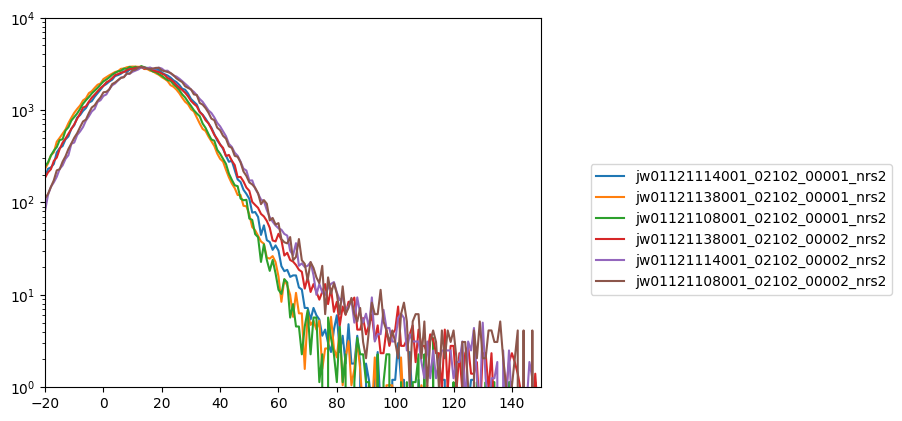

In [6]:
plt.figure()
i = 0
for item in jwst_pvd:
    pvd  = np.loadtxt(item) # pvd stands for pixel value distribution
    peak = np.argmax(pvd[:,1])+dn_min
    total_count = np.sum(pvd[:,1])
    rescale = 1e5 / total_count
    peakshift = 13 - peak
    plt.semilogy(pvd[:,0]+peakshift, pvd[:,1] * rescale, label = item.stem)
    #print(item.name + 'peak at: {}'.format(np.argmax(pvd[:,1])+dn_min))

plt.xlim(-20,150)
plt.ylim(1,1e4)
plt.legend(loc = (1.1,0.25))
plt.show()